# ini


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]=False
%matplotlib inline
import matplotlib.pyplot as plt

# Fine-tune specific elements
plt.rcParams['font.size'] = 12          # Global default
plt.rcParams['axes.titlesize'] = 15     # Individual subplot titles
plt.rcParams['axes.labelsize'] = 15     # x and y labels
plt.rcParams['xtick.labelsize'] = 14    # x-axis tick numbers
plt.rcParams['ytick.labelsize'] = 14    # y-axis tick numbers
tick_fs = 14
plt.rcParams['legend.fontsize'] = 13    # Legend text
plt.rcParams['figure.titlesize'] = 16   # Figure suptitle

In [2]:
from matplotlib import ticker


def load_alpha_grid(filename):
        # Load the pre-calculated grid
    with open(filename, "rb") as f:
        alpha_grid = pickle.load(f)
    return alpha_grid

import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

def plot_precalculated_alpha(alpha_grid, k_values, k_in, k_out, min_log=-5, max_log=7, figname= None):
    # 1. Prepare data
    log_k = np.log10(k_values)
    mask = (log_k >= min_log) & (log_k <= max_log)
    
    # 2. Safe Log Calculation
    floor_val = -6.0
    log_alpha_grid = np.full_like(alpha_grid, floor_val)
    np.log10(alpha_grid, where=(alpha_grid > 0), out=log_alpha_grid)
    
    # 3. Plotting
    plt.figure(figsize=(4, 3))
    filtered_k = log_k[mask]
    extent = [filtered_k[0], filtered_k[-1], filtered_k[0], filtered_k[-1]]

    # 4. Colormap Customization
    current_cmap = plt.colormaps.get_cmap('plasma').copy()
    current_cmap.set_under('black') 
    current_cmap.set_bad('black') 
    
    vmin = floor_val + 0.1 
    vmax = np.max(log_alpha_grid) if np.max(log_alpha_grid) > vmin else vmin + 1
    
    im = plt.imshow(log_alpha_grid, origin='lower', extent=extent,
                    aspect='auto', cmap=current_cmap, vmin=vmin, vmax=vmax)

    # 5. Fixed Colorbar Logic
    # We use extend='min' so the colorbar shows the 'under' color (black)
    fmt = ticker.FuncFormatter(lambda x, pos: f"$10^{{{int(x)}}}$")
    cbar = plt.colorbar(im, extend='min', format=fmt)
    
    # Clear existing ticks to prevent duplicates
    # We define our own ticks: the floor_val for 0, and then standard intervals
    desired_ticks = np.arange(np.ceil(vmin), np.floor(vmax) + 1, 2)
    all_ticks = np.sort(np.append(desired_ticks, floor_val))
    
    cbar.set_ticks(all_ticks)
    
    # Create labels: floor_val becomes $0$, others use scientific notation
    labels = []
    for t in all_ticks:
        if t == floor_val:
            labels.append("$0$")
        else:
            labels.append(f"$10^{{{int(t)}}}$")
    
    cbar.set_ticklabels(labels)
    cbar.ax.tick_params(labelsize=tick_fs)
    cbar.set_label(r'Growth Rate ($\alpha$)', rotation=270, labelpad=20)
    
    # 6. Axes Formatting
    ax = plt.gca()
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    
    plt.axvline(x=0, color='lightblue', linestyle='--', alpha=0.7)
    plt.xlabel(fr'$k_{{{k_in}}}$')
    plt.ylabel(fr'$k_{{{k_out}}}$')
    plt.tick_params(axis='both', labelsize=tick_fs)
    if figname:
        plt.savefig(f"../figures_TFM/{figname}.png", bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [3]:
def plot_r2_map(r2_grid, k_values, k_in, k_out, min_log=-5, max_log=7, figname=None):
    """
    Plots the pre-calculated R^2 grid as a heatmap.
    """
    # 1. Axis preparation and slicing
    log_k = np.log10(k_values)
    mask = (log_k >= min_log) & (log_k <= max_log)
    
    filtered_grid = r2_grid[mask][:, mask]
    filtered_k = log_k[mask]
    
    if filtered_grid.size == 0:
        print("No data in range.")
        return
        
    # 2. Plotting
    plt.figure(figsize=( 4, 3))
    extent = [filtered_k[0], filtered_k[-1], filtered_k[0], filtered_k[-1]]
    
    # Using 'inferno' as in your original code; 'viridis' is also great for 0-1 scales
    im = plt.imshow(filtered_grid, origin='lower', extent=extent, 
                    aspect='auto', cmap='viridis', vmin=0, vmax=1)
    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=tick_fs)
    cbar.set_label(r'$R^2$ of the fit', rotation=270, labelpad=20)
    
    # 3. Format the Colorbar to 10^n
    # This formatter takes the log value and turns it into a LaTeX power of 10
    fmt = ticker.FuncFormatter(lambda x, pos: f"$10^{{{int(x)}}}$")
    
    ax = plt.gca()
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    
    plt.xlabel(fr'$k_{{{k_in}}}$')
    plt.ylabel(fr'$k_{{{k_out}}}$')
    plt.tick_params(axis='both')
    if figname:
        plt.savefig(f"../figures_TFM/{figname}.png", bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    
def get_data_for_specific_k(raw_data, k_values, target_k_in, target_k_out):
    # 1. Find the indices in your k_change array
    # We use np.isclose to avoid floating point precision issues
    try:
        idx_k1 = np.where(np.isclose(k_values, target_k_out))[0][0]
        idx_k2 = np.where(np.isclose(k_values, target_k_in))[0][0]
    except IndexError:
        print(f"Values k1={target_k_out} or k2={target_k_in} not found in k_values.")
        return None

    # 2. Calculate the flat index 'i' used in the pickle
    n = len(k_values)
    target_idx = (idx_k1 * n) + idx_k2
    
    # 3. Search for this index in your loaded data
    if target_idx in raw_data:
        return raw_data[target_idx] # Returns the list of replicates
        
    print(f"Index {target_idx} not found in the provided data.")
    return None
def get_k_values_from_indices(row, col, k_values):
    """
    Translates grid row and column indices into the actual k values.
    
    Parameters:
    row (int): The row index (corresponding to the outer loop/y-axis).
    col (int): The column index (corresponding to the inner loop/x-axis).
    k_values (array): The array of k values used (e.g., k_change).
    
    Returns:
    tuple: (k_value_y, k_value_x)
    """
    if row >= len(k_values) or col >= len(k_values):
        return "Index out of bounds", "Index out of bounds"
    
    k_y = k_values[row] # alto
    k_x = k_values[col] # bajo
    
    return k_y, k_x

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

def plot_both(alpha_grid, r2_grid, k_values, k_in, k_out, min_log=-np.inf, max_log=np.inf, figname=None):
    if r2_grid.size == 0 or alpha_grid.size == 0:
        print("No data to plot.")
        return

    # 1. Prepare data & Setup Figure
    log_k = np.log10(k_values)
    mask = (log_k >= min_log) & (log_k <= max_log)
    filtered_k = log_k[mask]
    
    # Fallback if masking removes everything
    if len(filtered_k) == 0:
        filtered_k = log_k 
        
    extent = [filtered_k[0], filtered_k[-1], filtered_k[0], filtered_k[-1]]

    # 1 row, 2 columns layout. Made figsize wider (10, 4) to fit both colorbars nicely
    fig, axes = plt.subplots(1, 2, figsize=(9.5,3.75))
    ax1, ax2 = axes

    # Common formatter for both subplots
    fmt = ticker.FuncFormatter(lambda x, pos: f"$10^{{{int(x)}}}$")

    # ==========================================
    # LEFT COLUMN: Alpha Grid (Growth Rate)
    # ==========================================
    # Safe Log Calculation
    floor_val = -6.0
    log_alpha_grid = np.full_like(alpha_grid, floor_val)
    np.log10(alpha_grid, where=(alpha_grid > 0), out=log_alpha_grid)
    
    # Colormap Customization
    current_cmap = plt.colormaps.get_cmap('plasma').copy()
    current_cmap.set_under('black') 
    current_cmap.set_bad('black') 
    
    vmin = floor_val + 0.1 
    vmax = np.max(log_alpha_grid) if np.max(log_alpha_grid) > vmin else vmin + 1
    
    im1 = ax1.imshow(log_alpha_grid, origin='lower', extent=extent,
                     aspect='auto', cmap=current_cmap, vmin=vmin, vmax=vmax)

    # Colorbar Logic (attached strictly to ax1)
    cbar1 = fig.colorbar(im1, ax=ax1, extend='min', format=fmt)
    
    desired_ticks = np.arange(np.ceil(vmin), np.floor(vmax) + 1, 2)
    all_ticks = np.sort(np.append(desired_ticks, floor_val))
    cbar1.set_ticks(all_ticks)
    
    labels = ["$0$" if t == floor_val else f"$10^{{{int(t)}}}$" for t in all_ticks]
    cbar1.set_ticklabels(labels)
    cbar1.ax.tick_params(labelsize=tick_fs) # Assumes tick_fs is defined globally
    cbar1.set_label(r'Growth Rate ($\alpha$)', rotation=270, labelpad=20)
    
    # Axes Formatting for ax1
    ax1.xaxis.set_major_formatter(fmt)
    ax1.yaxis.set_major_formatter(fmt)
    ax1.set_xlabel(fr'$k_{{{k_in}}}$')
    ax1.set_ylabel(fr'$k_{{{k_out}}}$')
    ax1.tick_params(axis='both', labelsize=tick_fs)
    ax1.set_title("(A)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)



    # ==========================================
    # RIGHT COLUMN: R^2 Grid
    # ==========================================
    im2 = ax2.imshow(r2_grid, origin='lower', extent=extent, 
                     aspect='auto', cmap='viridis', vmin=0, vmax=1)
    
    # Colorbar Logic (attached strictly to ax2)
    cbar2 = fig.colorbar(im2, ax=ax2)
    cbar2.ax.tick_params(labelsize=tick_fs)
    cbar2.set_label(r'$R^2$ of the fit', rotation=270, labelpad=20)
    
    # Axes Formatting for ax2
    ax2.xaxis.set_major_formatter(fmt)
    ax2.yaxis.set_major_formatter(fmt)
    ax2.set_xlabel(fr'$k_{{{k_in}}}$')
    ax2.set_ylabel(fr'$k_{{{k_out}}}$')
    ax2.tick_params(axis='both', labelsize=tick_fs)
    ax2.set_title("(B)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)


    # ==========================================
    # FINAL LAYOUT AND SAVE
    # ==========================================
    plt.tight_layout()
    
    if figname:
        # dpi=300 makes sure it stays high-resolution for your TFM!
        plt.savefig(f"../figures_TFM/{figname}.png", bbox_inches='tight', dpi=300)
        
    plt.show()

# figuras

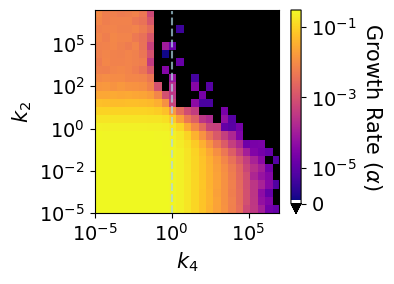

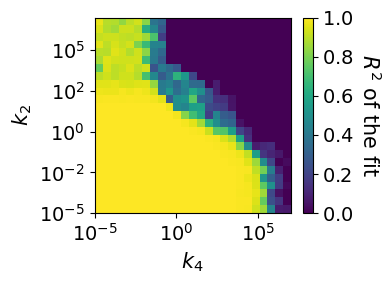

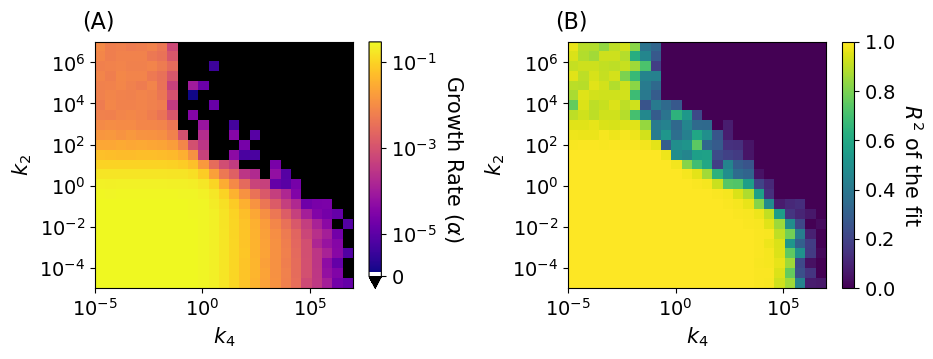

In [10]:
# Run the visualization
k2_vs_k4 = load_alpha_grid("alpha_sweep_k1_k3.pkl")
k_change = np.logspace(-5,7,25)

plot_precalculated_alpha(k2_vs_k4, k_change, k_in=4, k_out=2, figname="alpha_k2_vs_k4")


r2_grid = load_alpha_grid('r2_sweep_k1_k3.pkl')
plot_r2_map(r2_grid, k_change, 4, 2, figname="r2_k2_vs_k4")
plot_both(k2_vs_k4, r2_grid, k_change, 4, 2, figname="alpha_and_r2_k2_vs_k4")


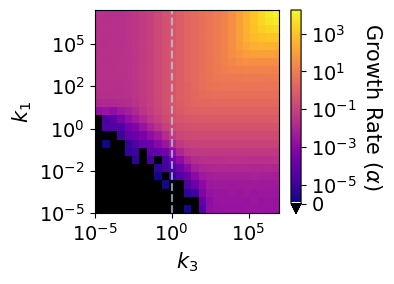

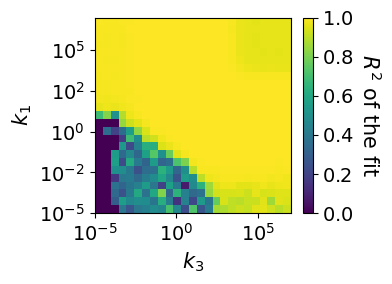

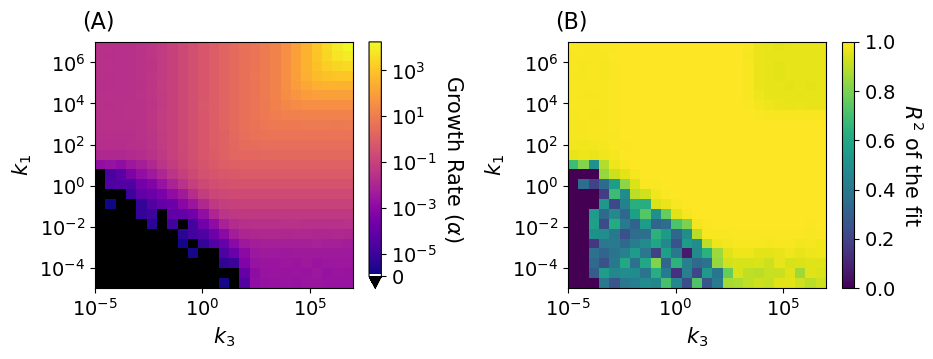

In [11]:
# Run the visualization
k1_vs_k3 = load_alpha_grid("alpha_sweep_k0_k2.pkl")
k_change = np.logspace(-5,7,25)

plot_precalculated_alpha(k1_vs_k3, k_change, k_in=3, k_out=1, figname="alpha_k1_vs_k3")


r2_grid = load_alpha_grid('r2_sweep_k0_k2.pkl')
plot_r2_map(r2_grid, k_change, 3, 1, figname="r2_k1_vs_k3")
plot_both(k1_vs_k3, r2_grid, k_change, 3, 1, figname="alpha_and_r2_k1_vs_k3")
